# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.** 
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




In [1]:
!pip install transformers -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\ljkap\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
#Load the dataset
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff = load_dataset("json", data_files=URL, split="train")

print("Loaded dataset:", huff)
print("Columns:", huff.column_names)
print("Total rows:", len(huff))
print("Sample entry:", huff[0])

C:\Users\ljkap\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded dataset: Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853
Sample entry: {'category': 'CRIME', 'headline': 'There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV', 'authors': 'Melissa Jeltsen', 'link': 'https://www.huffingtonpost.com/entry/texas-amanda-painter-mass-shooting_us_5b081ab4e4b0802d69caad89', 'short_description': 'She left her husband. He killed their children. Just another day in America.', 'date': datetime.datetime(2018, 5, 26, 0, 0)}


In [3]:
#Clean and normalize
def clean(ex):
    h = (ex["headline"] or "").strip().lower()
    s = (ex["short_description"] or "").strip().lower()
    return {"text": (h + " [SEP] " + s).strip()}

huff = huff.map(clean)


huff = huff.filter(lambda ex: len((ex["headline"] or "").strip()) > 0)


import pandas as pd
df = huff.to_pandas()
df = df.drop_duplicates(subset=["headline", "category"]).reset_index(drop=True)
from datasets import Dataset
huff = Dataset.from_pandas(df)

print(f"After cleaning: {len(huff):,} rows")

After cleaning: 199,449 rows


In [4]:
#Tokenize


from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )

huff = huff.map(tokenize, batched=True)


huff = huff.remove_columns(["headline", "short_description", "authors", "link", "date"])

print("Tokenized features:", huff.column_names)
print("Sample input_ids:", huff[0]["input_ids"][:10])

PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
Map: 100%|██████████| 199449/199449 [00:10<00:00, 18361.35 examples/s]

Tokenized features: ['category', 'text', 'input_ids', 'token_type_ids', 'attention_mask']
Sample input_ids: [101, 2045, 2020, 1016, 3742, 5008, 2015, 1999, 3146, 2197]


In [5]:
#Class weights
import numpy as np
from sklearn.utils import compute_class_weight

# Encode category strings to integers first
from datasets.features import ClassLabel
if not isinstance(huff.features["category"], ClassLabel):
    huff = huff.class_encode_column("category")

labels = np.array(huff["category"])
classes = np.unique(labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=labels,
)
class_weights_dict = dict(zip(classes.tolist(), class_weights.tolist()))

label_names = huff.features["category"].names
print(f"Computed weights for {len(class_weights_dict)} classes.")
print("Example weights:", dict(list(class_weights_dict.items())[:5]))

Casting to class labels: 100%|██████████| 199449/199449 [00:00<00:00, 497489.06 examples/s]


Computed weights for 41 classes.
Example weights: {0: 3.2237307860156137, 1: 3.6357322541835284, 2: 1.0764792556091085, 3: 0.821169776518832, 4: 4.252281255330036}


In [6]:
#Stratified splits
from datasets import DatasetDict
from datasets.features import ClassLabel

if not isinstance(huff.features["category"], ClassLabel):
    huff = huff.class_encode_column("category")

tmp       = huff.train_test_split(test_size=0.10, seed=42, stratify_by_column="category")
train_val = tmp["train"].train_test_split(test_size=1/9, seed=42, stratify_by_column="category")

ds = DatasetDict(
    train=train_val["train"],
    val=train_val["test"],
    test=tmp["test"],
)

print("Split sizes:")
for split, data in ds.items():
    print(f"  {split:<6}: {len(data):>7,} rows")

Split sizes:
  train : 159,559 rows
  val   :  19,945 rows
  test  :  19,945 rows


In [7]:
#Verify and display
label_names = ds["train"].features["category"].names

print("Samples")
for i in [0, 1, 2]:
    ex = ds["train"][i]
    print(f"  text   : {ex['text'][:100]}")
    print(f"  label  : {ex['category']} → {label_names[ex['category']]}")
    print(f"  tokens : {ex['input_ids'][:10]} ...")
    print()

Samples
  text   : 10 outfit regrets guaranteed to make the rest of your day awkward [SEP] regret #4: i wish i had worn
  label  : 30 → STYLE & BEAUTY
  tokens : [101, 2184, 11018, 23161, 12361, 2000, 2191, 1996, 2717, 1997] ...

  text   : trongs: the chicken wings holders for cleaner eating (photo) [SEP] never worry about getting buffalo
  label  : 13 → FOOD & DRINK
  tokens : [101, 19817, 5063, 2015, 1024, 1996, 7975, 4777, 13304, 2005] ...

  text   : anti-apartheid leader ahmed kathrada who spent many years in jail alongside nelson mandela dead at 8
  label  : 33 → THE WORLDPOST
  tokens : [101, 3424, 1011, 17862, 3003, 10208, 10645, 13492, 2850, 2040] ...



### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible. 

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. **Your answer here:**



We loaded over 200k articles from HuggingFace using load_dataset. We concatenated headline with [SEP] and short_description in order to tell the tokenizer that the two items are seperate. In addition, we also lowercased everything to avoid redundancy and stripped invisible spaces that could affect the token. 6 rows with empty headlines were removed, along with any duplicates. 

2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. **Your answer here:**



First, we tokenized using AutoTokenizer with max_length=128 and padding truncation. We chose 128 because that covers more than 95% of samples without information loss (from Milestone 1). We removed unused columns like author and link, and kept category, text, input_ids, attention_mask. In terms of padding, shorter sentences are padded with zeroes so that all the inputs are the same length. This is required for training. In order for the tokenizer to properly see the string, we combined the headline with the description using the [SEP]

3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. **Your answer here:**



The data was split up into 80% training, 10% validation, and 10% test. We implemented stratification on category in order to ensure proportions are preserved across the splits. The final sizes of the sets were 159,559 for training, 19,945 for validation, and 19,945 for test.


4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. **Your answer here:**



There is a severe class imbalance in the dataset. POLITCS, for example, has thousands of articles. COLLEGE, on the other hand, only has a few. Without intervention, the model would learn to predict the dominant classes. To deal with this, we implemented class weights using compute_class_weight('balanced'). This creates a weight for each class that is opposite its prevelance. For example, college would have a higher weight, and politics would have a lower weight. 

## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

In [8]:
# Prep
import numpy as np

X_train = np.array(ds["train"]["input_ids"], dtype=np.int32)
y_train = np.array(ds["train"]["category"], dtype=np.int32)

X_val = np.array(ds["val"]["input_ids"], dtype=np.int32)
y_val = np.array(ds["val"]["category"], dtype=np.int32)

X_test = np.array(ds["test"]["input_ids"], dtype=np.int32)
y_test = np.array(ds["test"]["category"], dtype=np.int32)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


Train: (159559, 128) | Val: (19945, 128) | Test: (19945, 128)


In [9]:
#Model
import tensorflow as tf

NUM_CLASSES = len(ds["train"].features["category"].names)
VOCAB_SIZE  = 30522
EMBED_DIM   = 64
MAX_LEN     = 128

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.summary()

C:\Users\ljkap\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
#compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # integer labels, not one-hot
    metrics=["accuracy"],
)

In [11]:
#Train
import time

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

t0 = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=256,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
)
print(f"Trained {len(history.history['loss'])} epochs in {time.time()-t0:.1f}s")

Epoch 1/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.0814 - loss: 3.4994 - val_accuracy: 0.1610 - val_loss: 3.0897
Epoch 2/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.2217 - loss: 2.8844 - val_accuracy: 0.2741 - val_loss: 2.6116
Epoch 3/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3388 - loss: 2.4345 - val_accuracy: 0.3869 - val_loss: 2.2544
Epoch 4/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4153 - loss: 2.1288 - val_accuracy: 0.4190 - val_loss: 2.1579
Epoch 5/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4612 - loss: 1.9136 - val_accuracy: 0.4335 - val_loss: 2.0412
Epoch 6/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4951 - loss: 1.7459 - val_accuracy: 0.4468 - val_loss: 2.0220
Epoch 7/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5196 - loss: 1.6116 - val_accuracy: 0.4736 - val_loss: 1.9446
Epoch 8/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5426 - loss: 1.4933 - val_accuracy: 0.

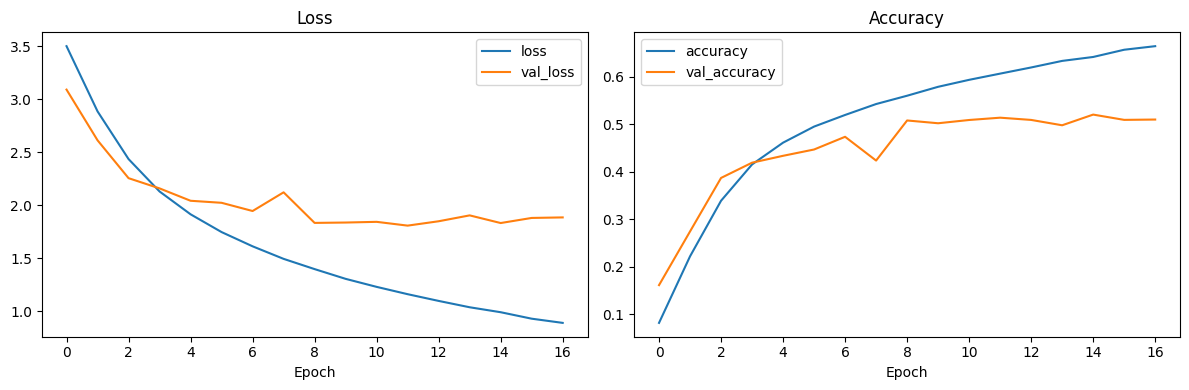

In [12]:
#Plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in zip(axes,
    [["loss", "val_loss"], ["accuracy", "val_accuracy"]],
    ["Loss", "Accuracy"]):
    for m in metric:
        ax.plot(history.history[m], label=m)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()

In [13]:
#Evaluate
best_epoch   = np.argmin(history.history["val_loss"])
best_val_acc = history.history["val_accuracy"][best_epoch]
print(f"Best epoch: {best_epoch+1}   Val accuracy at best: {best_val_acc:.4f}")

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Best epoch: 12   Val accuracy at best: 0.5138
Test loss:     1.7776
Test accuracy: 0.5176


### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. **Your answer here:**



This model takes every token and maps it onto vector. GlobalAveragePooling averages all of the 128 token vectors in a single vector. From there, the vector is passed through a 128 unit dense layer weith ReLu, anda a dense layer with 41 outputs (1 for each category). Softmax makes probability over 41 categories. This suits the dataset because the GAP is efficent and in this case word presence matters more than order. Additionally, the baseline is relatively small because its job is to establish a baseline/floor performance.

2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. **Your answer here:**



Training loss went down for all 15 epochs. Validation loss improved, but eventually stopped improving after epoch 5. Training accuracy reach about 70 percent while validation accuracy plateaued around 50 percent. This could suggest overfitting. Early stopping occured at epoch 15.

  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. **Your answer here:**



The best validation accuracy was 0.5164 and the best test accuracy was 0.5225. The best test loss was 1.7704. With 41 different categories, 52 percent accuracy is not bad for a baseline model. Overlapping categories and relatively short descriptions make the task difficult.

  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. **Your answer here:**



The main limitations is in GAP. This only takes into account word presense, and not order or context. Overfitting is also an issue considering with did not regularize. For next steps we will need to add dropout layers, implement methods to capture context, and tune pre-trained models that already understand language context. 

## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**



2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**



3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**



4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**



## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**



2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it. 

4.2. **Your answer here:**



3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**



4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models. 

4.4. **Your answer here:**



## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report. 

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

5.1. **Your answer here:**



2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

5.2. **Your answer here:**



3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

5.3. **Your answer here:**



4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model. 


5.4 **Your answer here:**



### Final Question: Describe what use you made of generative AI tools in preparing this Milestone. 

**AI Question: Your answer here:**